In [16]:
# ============================================================
# 01_exploration.ipynb
# Exploration des données de stock SAGE
# Changer BASE_NAME pour analyser une autre base 
# ============================================================

# ── Cellule 1 : Configuration ────────────────────────────────
BASE_NAME = 'BIJOU'   # ← changer ici pour STE_NGDM ou autre base pour l'analyse 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import create_engine, text
import pyodbc
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family']       = 'DejaVu Sans'
sns.set_palette('tab10')

print(f"✅ Configuration chargée — Base cible : {BASE_NAME}")

✅ Configuration chargée — Base cible : BIJOU


In [17]:
# ── Cellule 2 : Connexion SQL Server ─────────────────────────
# Adapter le connection string à ton environnement
# Si Windows Auth :  ?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes
# Si SQL Auth     :  username:password@serveur/...

SERVER   = 'SALMAIKSOD\SAGE100'          
DATABASE = 'Test'               

conn_str = (
    f"mssql+pyodbc://sa:123456@{SERVER}/{DATABASE}"
    f"?driver=ODBC+Driver+17+for+SQL+Server"
    f"&TrustServerCertificate=yes"
)

engine = create_engine(conn_str, fast_executemany=True)

# Test de connexion
try: 
    with engine.connect() as conn :
        result = conn.execute(text("SELECT DB_NAME() AS db")).fetchone()
        print(f"✅ Connexion OK — Base active : {result.db}")
except Exception as e:
    print(f"Erreur connexion : {e}")
    print("   Vérifier : nom serveur, driver ODBC installé, droits utilisateur")

✅ Connexion OK — Base active : Test


In [6]:
# ── Cellule 3 : Chargement via SP_GetStockJournalier 

query_bornes = """
SELECT 
    MIN(DateJour) AS date_min,
    MAX(DateJour) AS date_max
FROM Test.stock.VW_StockJoursAvecMvt
WHERE BaseName = :base
"""

with engine.connect() as conn:
    bornes = conn.execute(text(query_bornes), {'base': BASE_NAME}).fetchone()
    date_min_str = str(bornes.date_min)
    date_max_str = str(bornes.date_max)

print(f"Période disponible : {date_min_str} → {date_max_str}")

# Appel de la procédure avec toute la plage
# pyodbc direct (plus simple que SQLAlchemy pour les procédures)
conn_pyodbc = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"
    f"TrustServerCertificate=yes;"
)

query_proc = f"""
EXEC Test.stock.SP_GetStockJournalier
    @Base      = ?,
    @DateDebut = ?,
    @DateFin   = ?
"""

df_raw = pd.read_sql(
    query_proc,
    conn_pyodbc,
    params=[BASE_NAME, date_min_str, date_max_str]
)

conn_pyodbc.close()

print(f"✅ Données chargées : {len(df_raw):,} lignes")
print(f"   Colonnes reçues : {list(df_raw.columns)}")

Période disponible : 2025-01-02 → 2025-03-18
✅ Données chargées : 3,496 lignes
   Colonnes reçues : ['Date', 'Article', 'Designation', 'Code Famille', 'Intitule Famille', 'Cat N1 No', 'Cat N1', 'Cat N2 No', 'Cat N2', 'Cat N3 No', 'Cat N3', 'Cat N4 No', 'Cat N4', 'Depot', 'Nom Depot', 'Total Entrees', 'Total Sorties', 'Stock Initial', 'Stock Final', 'Valeur Initiale', 'Valeur Finale (Permanente)']


In [18]:
# ── Cellule 3b : Renommer les colonnes pour le ML ─────────────

renommage = {
    'Date':                      'DateJour',
    'Article':                   'AR_Ref',
    'Designation':               'AR_Design',
    'Code Famille':              'FA_CodeFamille',
    'Intitule Famille':          'FA_Intitule',
    'Cat N1 No':                 'CL_No1',
    'Cat N1':                    'CL_Intitule1',
    'Cat N2 No':                 'CL_No2',
    'Cat N2':                    'CL_Intitule2',
    'Cat N3 No':                 'CL_No3',
    'Cat N3':                    'CL_Intitule3',
    'Cat N4 No':                 'CL_No4',
    'Cat N4':                    'CL_Intitule4',
    'Depot':                     'DE_No',
    'Nom Depot':                 'DE_Intitule',
    'Total Entrees':             'TotalEntree',
    'Total Sorties':             'TotalSortie',
    'Stock Initial':             'StockInitial',
    'Stock Final':               'StockFinal',
    'Valeur Initiale':           'ValeurInitiale',
    'Valeur Finale (Permanente)':'ValeurFinale',
}

# On renomme seulement les colonnes qui existent
renommage_actif = {k: v for k, v in renommage.items() if k in df_raw.columns}
df_raw = df_raw.rename(columns=renommage_actif)

# Convertir les types
df_raw['DateJour']    = pd.to_datetime(df_raw['DateJour'])
df_raw['TotalEntree'] = pd.to_numeric(df_raw['TotalEntree'], errors='coerce').fillna(0)
df_raw['TotalSortie'] = pd.to_numeric(df_raw['TotalSortie'], errors='coerce').fillna(0)
df_raw['StockFinal']  = pd.to_numeric(df_raw['StockFinal'],  errors='coerce').fillna(0)
df_raw['ValeurFinale']= pd.to_numeric(df_raw['ValeurFinale'],errors='coerce').fillna(0)
df_raw['DE_No']       = pd.to_numeric(df_raw['DE_No'],       errors='coerce').fillna(0).astype(int)

print(f"✅ Colonnes normalisées")
print(f"   Articles : {df_raw['AR_Ref'].nunique()}")
print(f"   Dépôts   : {df_raw['DE_No'].nunique()}")
print(f"   Période  : {df_raw['DateJour'].min().date()} → {df_raw['DateJour'].max().date()}")
df_raw.head(3)

✅ Colonnes normalisées
   Articles : 45
   Dépôts   : 2
   Période  : 2025-01-02 → 2025-03-18


,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,CL_No1,CL_Intitule1,CL_No2,CL_Intitule2,CL_No3,...,DE_Intitule,TotalEntree,TotalSortie,StockInitial,StockFinal,ValeurInitiale,ValeurFinale,jour_semaine,mois,annee
0,2025-01-02,BAAR01,Bague Argent,BIJOUXARG,Bijouterie Argent,2,Bijoux,11,Argent,13,...,Bijou SA,5.0,0.0,0.0,5.0,0.00,762.60,Thursday,1,2025
1,2025-01-03,BAAR01,Bague Argent,BIJOUXARG,Bijouterie Argent,2,Bijoux,11,Argent,13,...,Bijou SA,10.0,4.0,5.0,11.0,762.60,1923.24,Friday,1,2025
2,2025-01-04,BAAR01,Bague Argent,BIJOUXARG,Bijouterie Argent,2,Bijoux,11,Argent,13,...,Bijou SA,0.0,0.0,11.0,11.0,1923.24,1923.24,Saturday,1,2025


In [19]:
# ── Cellule 4 : Qualité des données ──────────────────────────
print("=" * 55)
print(f"RAPPORT QUALITÉ — {BASE_NAME}")
print("=" * 55)

# Valeurs manquantes
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
df_missing = pd.DataFrame({
    'Manquants': missing,
    'Pourcentage %': missing_pct
}).query('Manquants > 0')

if df_missing.empty:
    print("\n✅ Aucune valeur manquante")
else:
    print("\n⚠️  Valeurs manquantes :")
    print(df_missing.to_string())

# Types de colonnes
print(f"\n📋 Types de données :")
print(df_raw.dtypes.to_string())

# Stats descriptives colonnes numériques
print(f"\n📊 Statistiques descriptives :")
print(df_raw[['TotalEntree','TotalSortie','StockFinal','ValeurFinale']].describe().round(2).to_string())

RAPPORT QUALITÉ — BIJOU

⚠️  Valeurs manquantes :
              Manquants  Pourcentage %
CL_Intitule2        152           4.35
CL_Intitule3       2584          73.91
CL_Intitule4       3344          95.65

📋 Types de données :
DateJour          datetime64[s]
AR_Ref                      str
AR_Design                   str
FA_CodeFamille              str
FA_Intitule                 str
CL_No1                    int64
CL_Intitule1                str
CL_No2                    int64
CL_Intitule2                str
CL_No3                    int64
CL_Intitule3                str
CL_No4                    int64
CL_Intitule4                str
DE_No                     int64
DE_Intitule                 str
TotalEntree             float64
TotalSortie             float64
StockInitial            float64
StockFinal              float64
ValeurInitiale          float64
ValeurFinale            float64
jour_semaine                str
mois                      int32
annee                     int32

📊 S

Articles avec > 90 jours d'historique : 1
Articles avec > 30 jours d'historique : 45
Articles avec <= 30 jours (non prévisibles) : 0


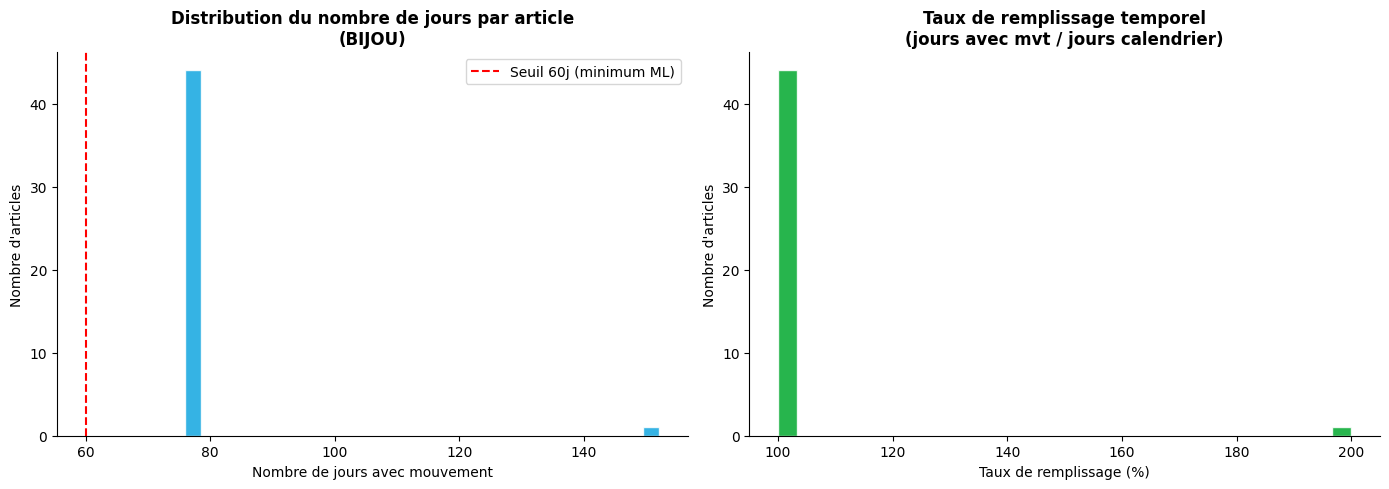


✅ Graphique sauvegardé


In [20]:
# ── Cellule 5 : Distribution de l'historique par article ─────
# Nombre de jours d'historique disponible par article
hist_par_article = (
    df_raw.groupby('AR_Ref')['DateJour']
    .agg(nb_jours='count', date_min='min', date_max='max')
    .assign(jours_calendrier=lambda x: (x['date_max'] - x['date_min']).dt.days + 1)
    .assign(taux_remplissage=lambda x: (x['nb_jours'] / x['jours_calendrier'] * 100).round(1))
    .sort_values('nb_jours', ascending=False)
    .reset_index()
)

print(f"Articles avec > 90 jours d'historique : {(hist_par_article['nb_jours'] > 90).sum()}")
print(f"Articles avec > 30 jours d'historique : {(hist_par_article['nb_jours'] > 30).sum()}")
print(f"Articles avec <= 30 jours (non prévisibles) : {(hist_par_article['nb_jours'] <= 30).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hist_par_article['nb_jours'], bins=30, color='#12a6e0', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Distribution du nombre de jours par article\n({BASE_NAME})', fontweight='bold')
axes[0].set_xlabel("Nombre de jours avec mouvement")
axes[0].set_ylabel("Nombre d'articles")
axes[0].axvline(60, color='red', linestyle='--', linewidth=1.5, label='Seuil 60j (minimum ML)')
axes[0].legend()

axes[1].hist(hist_par_article['taux_remplissage'], bins=30, color='#01a82e', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Taux de remplissage temporel\n(jours avec mvt / jours calendrier)', fontweight='bold')
axes[1].set_xlabel("Taux de remplissage (%)")
axes[1].set_ylabel("Nombre d'articles")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_01_historique_articles.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé")

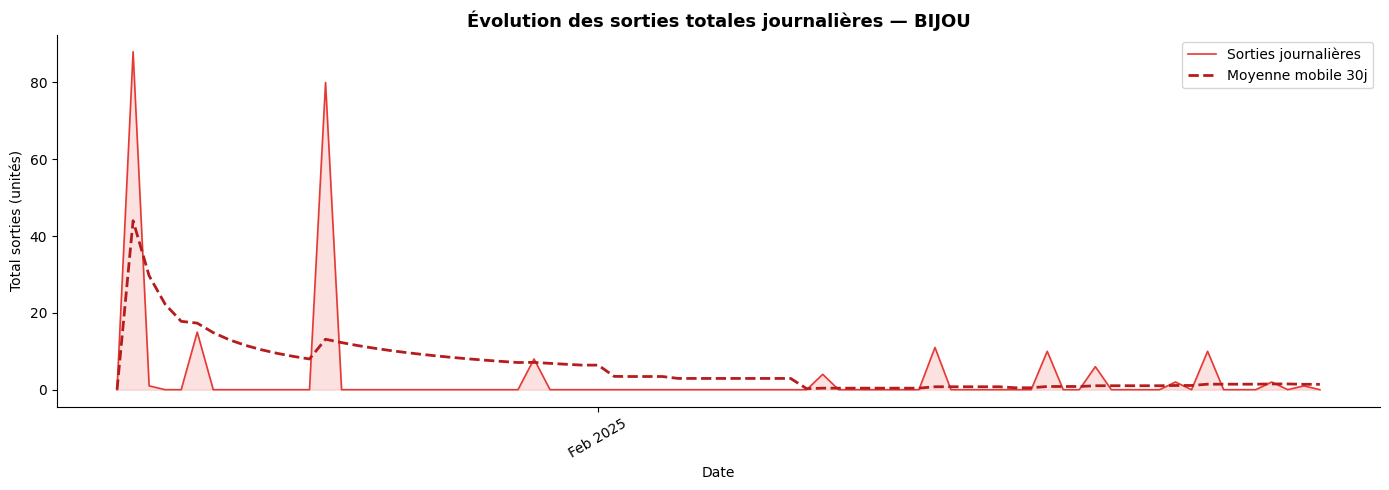

In [21]:
# ── Cellule 6 : Évolution globale des sorties dans le temps ──
sorties_jour = (
    df_raw.groupby('DateJour')['TotalSortie']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(sorties_jour['DateJour'], sorties_jour['TotalSortie'],
                alpha=0.15, color='#e53935')
ax.plot(sorties_jour['DateJour'], sorties_jour['TotalSortie'],
        color='#e53935', linewidth=1.2, label='Sorties journalières')

# Moyenne mobile 30j
sorties_jour['ma30'] = sorties_jour['TotalSortie'].rolling(30, min_periods=1).mean()
ax.plot(sorties_jour['DateJour'], sorties_jour['ma30'],
        color='#b71c1c', linewidth=2, linestyle='--', label='Moyenne mobile 30j')

ax.set_title(f'Évolution des sorties totales journalières — {BASE_NAME}', fontweight='bold', fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Total sorties (unités)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_02_sorties_globales.png', dpi=150, bbox_inches='tight')
plt.show()

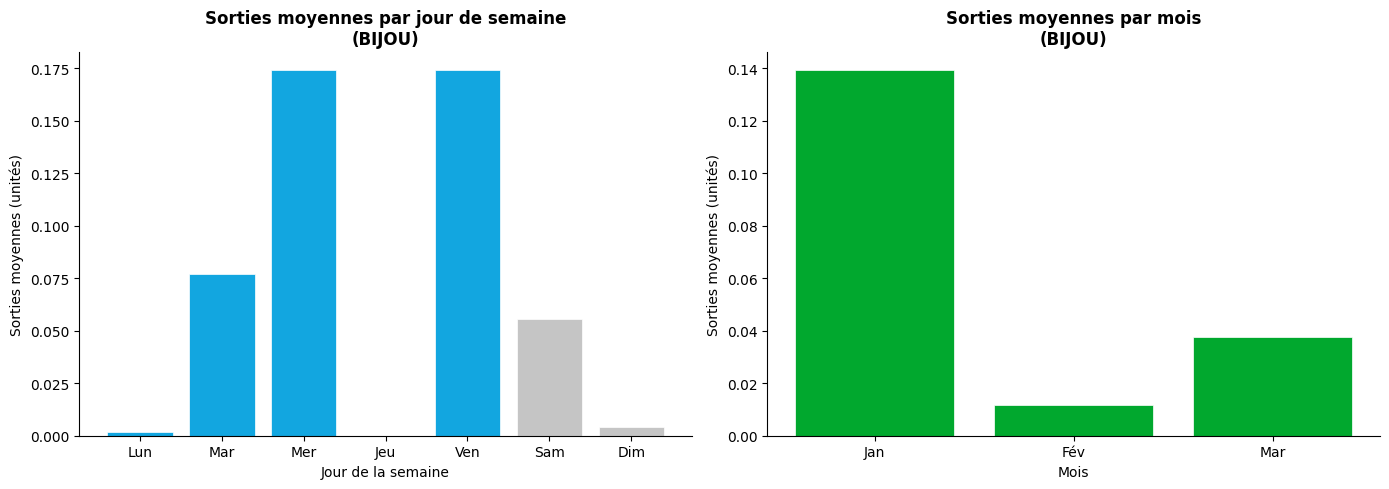

In [22]:
# ── Cellule 7 : Saisonnalité hebdomadaire ────────────────────
df_raw['jour_semaine'] = df_raw['DateJour'].dt.day_name()
df_raw['mois']         = df_raw['DateJour'].dt.month
df_raw['annee']        = df_raw['DateJour'].dt.year

ordre_jours = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
labels_fr   = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']

sorties_semaine = (
    df_raw.groupby('jour_semaine')['TotalSortie']
    .mean()
    .reindex(ordre_jours)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_week = ['#12a6e0' if j not in ['Saturday','Sunday'] else '#c5c5c5' for j in ordre_jours]
axes[0].bar(labels_fr, sorties_semaine.values, color=colors_week, edgecolor='white', linewidth=0.5)
axes[0].set_title(f'Sorties moyennes par jour de semaine\n({BASE_NAME})', fontweight='bold')
axes[0].set_xlabel("Jour de la semaine")
axes[0].set_ylabel("Sorties moyennes (unités)")

sorties_mois = df_raw.groupby('mois')['TotalSortie'].mean()
noms_mois = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']
axes[1].bar(
    [noms_mois[m-1] for m in sorties_mois.index],
    sorties_mois.values,
    color='#01a82e', edgecolor='white', linewidth=0.5
)
axes[1].set_title(f'Sorties moyennes par mois\n({BASE_NAME})', fontweight='bold')
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Sorties moyennes (unités)")

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_03_saisonnalite.png', dpi=150, bbox_inches='tight')
plt.show()

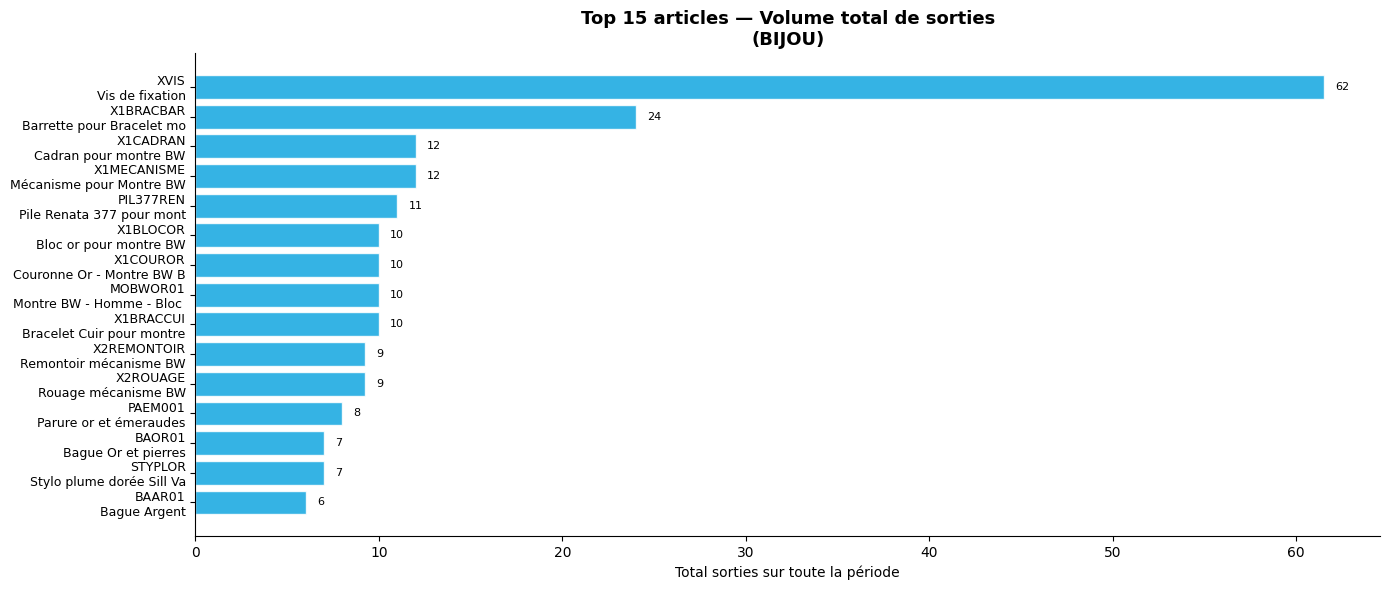

In [23]:
# ── Cellule 8 : Top articles par volume de sorties ───────────
top_articles = (
    df_raw.groupby(['AR_Ref', 'AR_Design'])['TotalSortie']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_articles['label'] = top_articles['AR_Ref'] + '\n' + top_articles['AR_Design'].str[:25]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(range(len(top_articles)), top_articles['TotalSortie'],
               color='#12a6e0', edgecolor='white', alpha=0.85)
ax.set_yticks(range(len(top_articles)))
ax.set_yticklabels(top_articles['label'], fontsize=9)
ax.invert_yaxis()
ax.set_title(f'Top 15 articles — Volume total de sorties\n({BASE_NAME})', fontweight='bold', fontsize=13)
ax.set_xlabel("Total sorties sur toute la période")

for bar, val in zip(bars, top_articles['TotalSortie']):
    ax.text(bar.get_width() + max(top_articles['TotalSortie']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_04_top_articles.png', dpi=150, bbox_inches='tight')
plt.show()

Articles avec stock minimum <= 0 : 45
Articles ayant été à zéro au moins 1 jour : 45


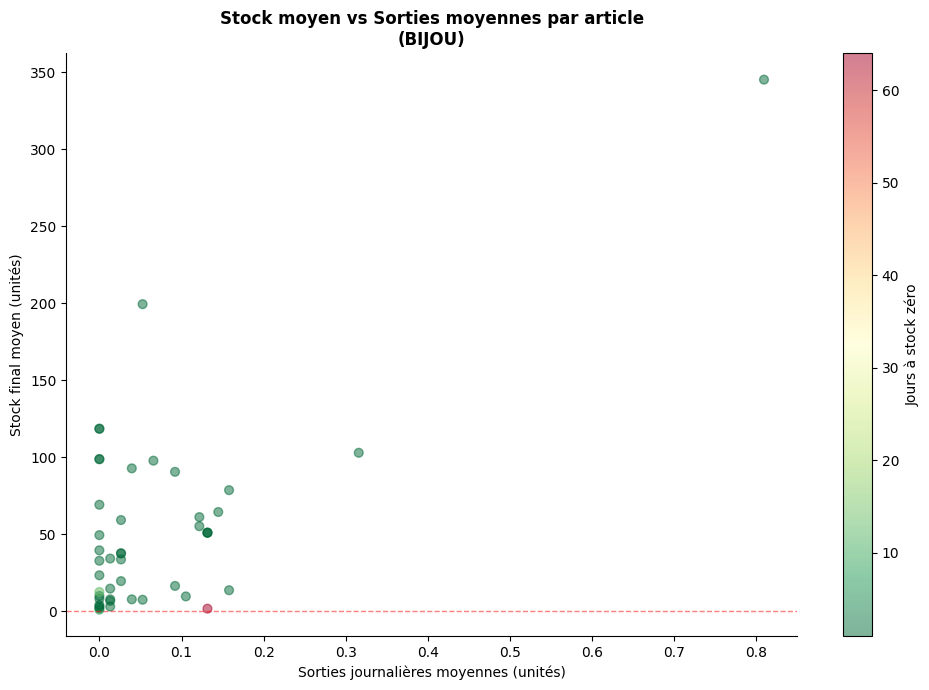

In [24]:
# ── Cellule 9 : Analyse stock final et risques rupture ────────
# Articles dont le stock final moyen est faible
stock_moyen = (
    df_raw.groupby(['AR_Ref', 'AR_Design'])
    .agg(
        stock_moyen=('StockFinal', 'mean'),
        stock_min=('StockFinal', 'min'),
        stock_max=('StockFinal', 'max'),
        sorties_moy=('TotalSortie', 'mean'),
        nb_jours_zero=('StockFinal', lambda x: (x <= 0).sum())
    )
    .reset_index()
    .sort_values('stock_moyen')
)

print(f"Articles avec stock minimum <= 0 : {(stock_moyen['stock_min'] <= 0).sum()}")
print(f"Articles ayant été à zéro au moins 1 jour : {(stock_moyen['nb_jours_zero'] > 0).sum()}")

# Scatter : stock moyen vs sorties moyennes
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    stock_moyen['sorties_moy'],
    stock_moyen['stock_moyen'],
    alpha=0.5,
    c=stock_moyen['nb_jours_zero'],
    cmap='RdYlGn_r',
    s=40
)
plt.colorbar(scatter, ax=ax, label='Jours à stock zéro')
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title(f'Stock moyen vs Sorties moyennes par article\n({BASE_NAME})', fontweight='bold')
ax.set_xlabel("Sorties journalières moyennes (unités)")
ax.set_ylabel("Stock final moyen (unités)")
plt.tight_layout()
plt.savefig(f'../outputs/{BASE_NAME}_05_stock_vs_sorties.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── Cellule 10 : Résumé final de l'exploration ───────────────
articles_previsibles = hist_par_article[hist_par_article['nb_jours'] >= 60]
articles_risque      = stock_moyen[stock_moyen['nb_jours_zero'] > 5]

print("=" * 55)
print(f"RÉSUMÉ EXPLORATION — {BASE_NAME}")
print("=" * 55)
print(f"\n📦 Articles total          : {df_raw['AR_Ref'].nunique()}")
print(f"✅ Prévisibles (>= 60j)    : {len(articles_previsibles)}")
print(f"⚠️  Non prévisibles (<60j)  : {df_raw['AR_Ref'].nunique() - len(articles_previsibles)}")
print(f"🔴 Articles à risque rupture : {len(articles_risque)}")
print(f"\n📅 Période totale          : {df_raw['DateJour'].min().date()} → {df_raw['DateJour'].max().date()}")
print(f"📈 Jours avec mouvement    : {df_raw['DateJour'].nunique()}")

# Sauvegarder la liste des articles prévisibles pour notebook 02
articles_previsibles[['AR_Ref']].to_csv(
    f'../outputs/{BASE_NAME}_articles_previsibles.csv', index=False
)
print(f"\n✅ Liste articles prévisibles sauvegardée")

RÉSUMÉ EXPLORATION — BIJOU

📦 Articles total          : 45
✅ Prévisibles (>= 60j)    : 45
⚠️  Non prévisibles (<60j)  : 0
🔴 Articles à risque rupture : 3

📅 Période totale          : 2025-01-02 → 2025-03-18
📈 Jours avec mouvement    : 76

✅ Liste articles prévisibles sauvegardée
